# Lab 4 — KNN Classification (Breast Cancer) & Comparison with Regression Metrics

**Aim:** Implement KNN classification on the Breast Cancer dataset and analyze performance using
train-test split, heuristic *K* selection, cross-validation, ROC-AUC and classification metrics,
then compare classification metrics against the regression metrics from Lab 3.

**Dataset:** Breast Cancer Wisconsin (Diagnostic) — 569 samples, 30 numeric features.
Target: `0 = Malignant`, `1 = Benign`.


## 0. Imports & Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report,
                             roc_curve, auc, RocCurveDisplay)
from sklearn.decomposition import PCA

sns.set(style="whitegrid")
np.random.seed(42) 
RANDOM_STATE = 42

## Task 1 — Data Preparation

1. Load the dataset. 2. Convert to a DataFrame and explore. 3. Check missing values & duplicates.
4. Apply `StandardScaler` and justify it.

> **Note on the target encoding.** The lab defines `0 = Malignant`, `1 = Benign`.
> The CSV stores the label as `"M"` / `"B"`, so we map `M → 0`, `B → 1` to match the lab.
> (sklearn's built-in `load_breast_cancer` uses `0 = Malignant`, `1 = Benign` as well, so both routes agree.)


In [ ]:

df = pd.read_csv("brca.csv", index_col=0)
    # columns look like x.radius_mean ... y  -> clean names & map target
df.columns = [c.replace("x.", "") for c in df.columns]
df["y"] = df["y"].map({"M": 0, "B": 1})   # lab encoding: Malignant=0, Benign=1
X = df.drop(columns="y")
y = df["y"]
feature_names = X.columns.tolist()
print("Loaded from brca.csv")

print("Shape:", df.shape)
df.head()

Loaded from brca.csv
Shape: (569, 31)


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_pts_mean,symmetry_mean,fractal_dim_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_pts_worst,symmetry_worst,fractal_dim_worst,y
1,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,0.05766,...,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259,1
2,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,0.06811,...,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183,1
3,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,0.06905,...,15.66,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773,1
4,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,0.05863,...,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169,1
5,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,0.06503,...,21.96,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409,1


In [ ]:
# Structure & summary
df.info()
df.describe().T.head() 

<class 'pandas.core.frame.DataFrame'>
Index: 569 entries, 1 to 569
Data columns (total 31 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   radius_mean        569 non-null    float64
 1   texture_mean       569 non-null    float64
 2   perimeter_mean     569 non-null    float64
 3   area_mean          569 non-null    float64
 4   smoothness_mean    569 non-null    float64
 5   compactness_mean   569 non-null    float64
 6   concavity_mean     569 non-null    float64
 7   concave_pts_mean   569 non-null    float64
 8   symmetry_mean      569 non-null    float64
 9   fractal_dim_mean   569 non-null    float64
 10  radius_se          569 non-null    float64
 11  texture_se         569 non-null    float64
 12  perimeter_se       569 non-null    float64
 13  area_se            569 non-null    float64
 14  smoothness_se      569 non-null    float64
 15  compactness_se     569 non-null    float64
 16  concavity_se       569 non-null

,count,mean,std,min,25%,50%,75%,max
radius_mean,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.7800,28.1100
texture_mean,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.8000,39.2800
perimeter_mean,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.1000,188.5000
area_mean,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.7000,2501.0000
smoothness_mean,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.1053,0.1634


y
1    357
0    212
Name: count, dtype: int64

Class balance (%):
y
1    62.74
0    37.26
Name: proportion, dtype: float64


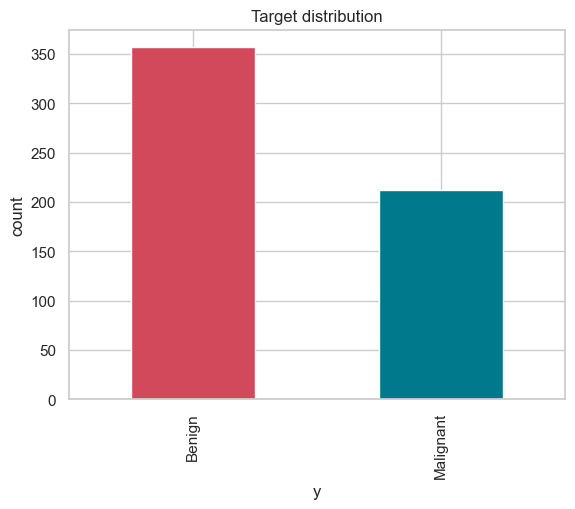

In [6]:
# Target distribution  (0 = Malignant, 1 = Benign)
print(y.value_counts())
print("\nClass balance (%):")
print((y.value_counts(normalize=True)*100).round(2))

ax = y.map({0:"Malignant", 1:"Benign"}).value_counts().plot(kind="bar", color=["#d1495b","#00798c"])
ax.set_title("Target distribution"); ax.set_ylabel("count"); plt.show()

In [7]:
# Missing values & duplicates
print("Total missing values:", df.isnull().sum().sum())
print("Duplicate rows      :", df.duplicated().sum())

Total missing values: 0
Duplicate rows      : 0


In [8]:
# Feature scaling with StandardScaler  (z = (x - mean) / std)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=feature_names, index=X.index)

print("Before scaling  -> mean of area_mean:", round(X['area_mean'].mean(),2),
      "| std:", round(X['area_mean'].std(),2))
print("After scaling   -> mean:", round(X_scaled['area_mean'].mean(),4),
      "| std:", round(X_scaled['area_mean'].std(),4))
X_scaled.describe().T[['mean','std']].head()

Before scaling  -> mean of area_mean: 654.89 | std: 351.91
After scaling   -> mean: -0.0 | std: 1.0009


,mean,std
radius_mean,-1.998011e-16,1.00088
texture_mean,-7.492542e-16,1.00088
perimeter_mean,-9.990056e-17,1.00088
area_mean,-1.998011e-16,1.00088
smoothness_mean,1.498508e-16,1.00088


**Why scaling matters for KNN.** KNN classifies a point by the distance to its neighbours.
Features here live on wildly different scales — `area_mean` is in the hundreds while `smoothness_mean`
is ~0.1. Without scaling, the large-magnitude features dominate the Euclidean distance and the small
ones are effectively ignored. `StandardScaler` gives every feature mean 0 and std 1, so each feature
contributes fairly to the distance. Scaling is essential for any distance-based model (KNN, SVM, K-Means).


## Task 2 — Train-Test Split Analysis

Compare an 80:20, 70:30 and 90:10 split. We use `stratify=y` so each split keeps the same class ratio,
and a fixed baseline `K` (here `K=5`) so that only the split changes.

In [9]:
split_sizes = {"80:20": 0.20, "70:30": 0.30, "90:10": 0.10}
split_results = []

for name, ts in split_sizes.items():
    Xtr, Xte, ytr, yte = train_test_split(X_scaled, y, test_size=ts,
                                           stratify=y, random_state=RANDOM_STATE)
    knn = KNeighborsClassifier(n_neighbors=5).fit(Xtr, ytr)
    train_acc = knn.score(Xtr, ytr)
    test_acc  = knn.score(Xte, yte)
    split_results.append([name, len(Xtr), len(Xte), round(train_acc,4), round(test_acc,4)])

split_df = pd.DataFrame(split_results,
             columns=["Split","Train n","Test n","Train Acc","Test Acc"])
split_df

,Split,Train n,Test n,Train Acc,Test Acc
0,80:20,455,114,0.9736,0.9649
1,70:30,398,171,0.9698,0.9708
2,90:10,512,57,0.9805,0.9825


**Reading the table.** Test accuracy stays high and fairly stable (~0.95–0.97) across all three
splits, which tells us the model generalizes well and isn't overly sensitive to how we split. The 90:10
split has the smallest test set (57 rows), so its test accuracy is the noisiest — a couple of
mis-classifications move the number a lot. The 70:30 split gives the most trustworthy estimate because
the test set is largest. A single split is still only *one* estimate; Task 4 (cross-validation) averages
over many splits for a more reliable number.

## Task 3 — KNN with Heuristic *K* Selection

### 3.1 Heuristic rule: $K = \sqrt{n}$  (n = number of training samples)

In [10]:
# Use the 80:20 split as our working split from here on
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)

n_train = len(X_train)
K_heuristic = int(round(np.sqrt(n_train)))
if K_heuristic % 2 == 0:           # prefer an odd K to avoid ties in binary classification
    K_heuristic += 1
print(f"n_train = {n_train}  ->  sqrt(n) = {np.sqrt(n_train):.2f}  ->  baseline K = {K_heuristic}")

n_train = 455  ->  sqrt(n) = 21.33  ->  baseline K = 21


### 3.2 Model training — baseline K and a sweep of K ± 5

In [11]:
# Baseline model at the heuristic K
knn_base = KNeighborsClassifier(n_neighbors=K_heuristic).fit(X_train, y_train)
print(f"Baseline (K={K_heuristic}) test accuracy: {knn_base.score(X_test, y_test):.4f}")

# Sweep nearby K values (K-5 .. K+5), keep K >= 1
k_lo = max(1, K_heuristic - 5)
k_range = range(k_lo, K_heuristic + 6)
acc_by_k = {k: KNeighborsClassifier(n_neighbors=k).fit(X_train, y_train).score(X_test, y_test)
            for k in k_range}

best_k_tt = max(acc_by_k, key=acc_by_k.get)
for k, a in acc_by_k.items():
    print(f"K={k:2d}  acc={a:.4f}" + ("   <-- best" if k == best_k_tt else ""))

Baseline (K=21) test accuracy: 0.9561
K=16  acc=0.9737
K=17  acc=0.9737
K=18  acc=0.9825   <-- best
K=19  acc=0.9737
K=20  acc=0.9649
K=21  acc=0.9561
K=22  acc=0.9561
K=23  acc=0.9649
K=24  acc=0.9561
K=25  acc=0.9649
K=26  acc=0.9561


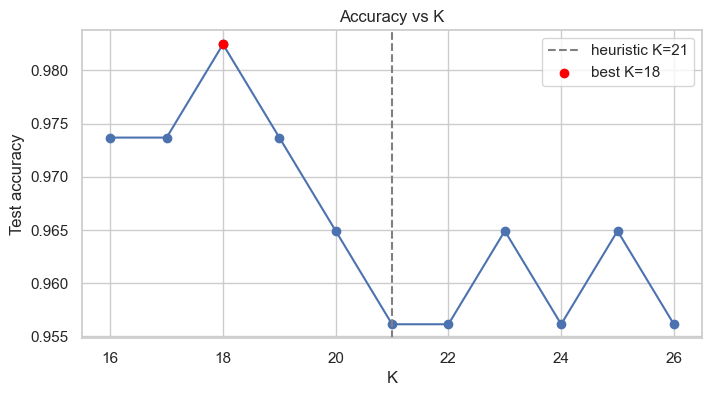

In [12]:
# Accuracy vs K plot
plt.figure(figsize=(8,4))
plt.plot(list(acc_by_k.keys()), list(acc_by_k.values()), marker="o")
plt.axvline(K_heuristic, ls="--", color="gray", label=f"heuristic K={K_heuristic}")
plt.scatter([best_k_tt], [acc_by_k[best_k_tt]], color="red", zorder=5,
            label=f"best K={best_k_tt}")
plt.xlabel("K"); plt.ylabel("Test accuracy"); plt.title("Accuracy vs K")
plt.legend(); plt.show()

### 3.3 Distance metrics & decision boundaries

**Euclidean distance** (`metric='euclidean'`, the default): straight-line distance,
$d=\sqrt{\sum_i (a_i-b_i)^2}$. Best when features are continuous, scaled, and directions are equally
meaningful — the common default.

**Manhattan distance** (`metric='manhattan'`): sum of absolute differences,
$d=\sum_i |a_i-b_i|$. More robust to outliers and often preferred in high-dimensional or sparse data,
or where movement is grid-like / features are independent.

Below we visualize how the decision boundary changes with K. To draw a 2-D boundary we project the
scaled features to their **first two principal components** (PCA) purely for visualization.

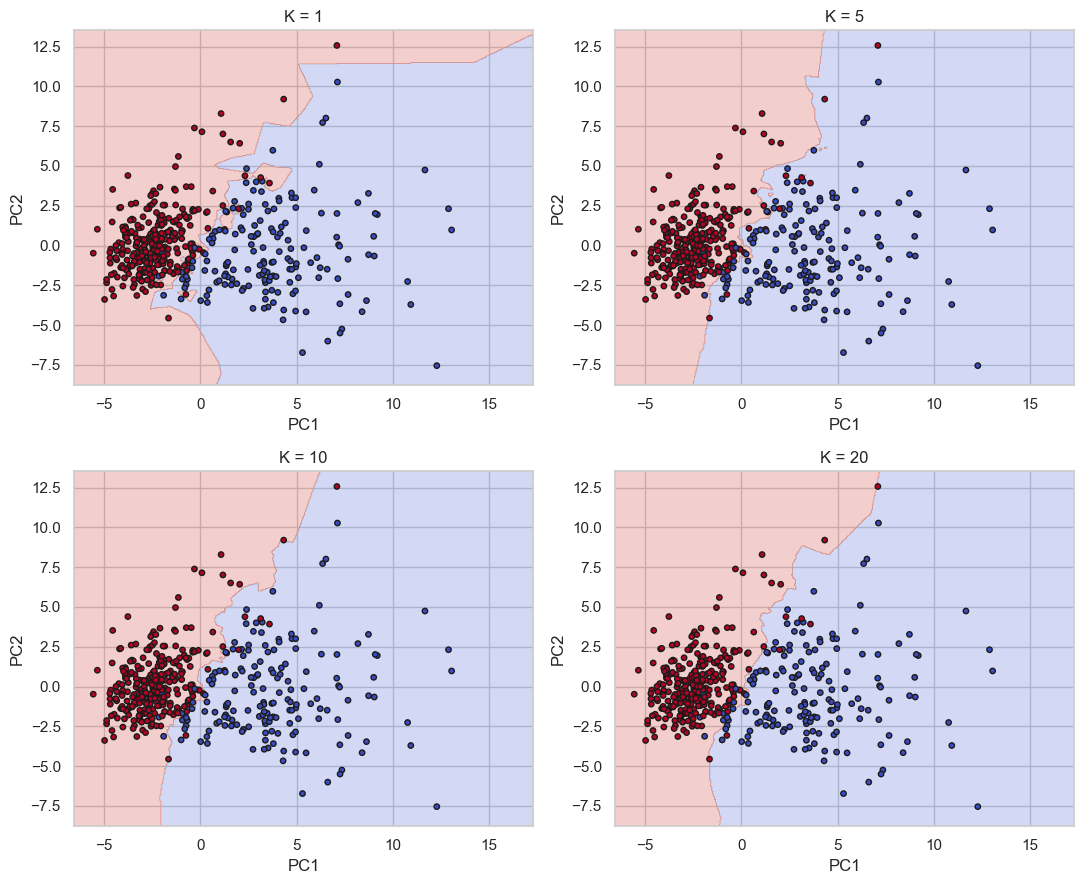

In [13]:
# 2-D projection for visualization only
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X2 = pca.fit_transform(X_scaled)
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)

def plot_boundary(ax, k):
    clf = KNeighborsClassifier(n_neighbors=k).fit(X2_train, y2_train)
    h = 0.05
    x_min, x_max = X2[:,0].min()-1, X2[:,0].max()+1
    y_min, y_max = X2[:,1].min()-1, X2[:,1].max()+1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap="coolwarm")
    ax.scatter(X2_train[:,0], X2_train[:,1], c=y2_train, cmap="coolwarm",
               edgecolor="k", s=15)
    ax.set_title(f"K = {k}"); ax.set_xlabel("PC1"); ax.set_ylabel("PC2")

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for ax, k in zip(axes.ravel(), [1, 5, 10, 20]):
    plot_boundary(ax, k)
plt.tight_layout(); plt.show()

**How the boundary changes with K.** At `K=1` the boundary is jagged and wraps around individual
points — low bias, high variance, and it memorizes noise (overfitting). As K grows (5 → 10 → 20) the
boundary gets smoother and more stable — higher bias, lower variance. Very large K over-smooths and can
start ignoring genuine local structure (underfitting). This is the bias-variance trade-off in action.

## Task 4 — Cross-Validation

We run Stratified K-Fold cross-validation (k=10 folds) over a range of K values, on the **full scaled
dataset**, and pick the K with the best mean accuracy. CV averages over many splits, so it's a far more
reliable estimate than the single train-test number from Task 3.

In [14]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

k_values = range(1, 31)
cv_means, cv_stds = [], []
for k in k_values:
    scores = cross_val_score(KNeighborsClassifier(n_neighbors=k),
                             X_scaled, y, cv=cv, scoring="accuracy")
    cv_means.append(scores.mean()); cv_stds.append(scores.std())

cv_means = np.array(cv_means); cv_stds = np.array(cv_stds)
best_k_cv = list(k_values)[int(np.argmax(cv_means))]
print(f"Best K by 10-fold CV: {best_k_cv}  (mean acc = {cv_means.max():.4f})")

Best K by 10-fold CV: 14  (mean acc = 0.9737)


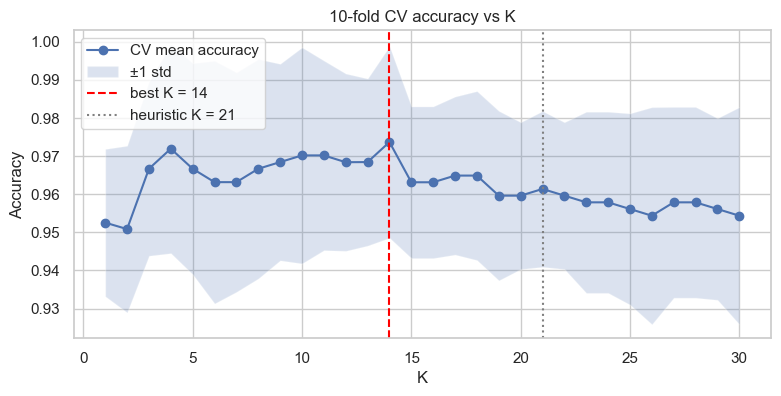

In [15]:
plt.figure(figsize=(9,4))
plt.plot(list(k_values), cv_means, marker="o", label="CV mean accuracy")
plt.fill_between(list(k_values), cv_means-cv_stds, cv_means+cv_stds, alpha=0.2,
                 label="±1 std")
plt.axvline(best_k_cv, ls="--", color="red", label=f"best K = {best_k_cv}")
plt.axvline(K_heuristic, ls=":", color="gray", label=f"heuristic K = {K_heuristic}")
plt.xlabel("K"); plt.ylabel("Accuracy"); plt.title("10-fold CV accuracy vs K")
plt.legend(); plt.show()

In [16]:
print("Comparison of K-selection methods")
print("-"*45)
print(f"Heuristic  sqrt(n)         : K = {K_heuristic}")
print(f"Best train-test split acc : K = {best_k_tt}")
print(f"Best 10-fold CV accuracy  : K = {best_k_cv}")

FINAL_K = best_k_cv          # trust cross-validation for the final model
print(f"\n>>> Final K chosen = {FINAL_K}")

Comparison of K-selection methods
---------------------------------------------
Heuristic  sqrt(n)         : K = 21
Best train-test split acc : K = 18
Best 10-fold CV accuracy  : K = 14

>>> Final K chosen = 14


**Why trust CV.** The single train-test split can get lucky or unlucky depending on which rows land
in the test set. 10-fold CV trains and tests on 10 different partitions and averages, so the score has
much lower variance and generalizes better. We adopt the CV-selected K as our **final K**.

## Task 5 — Classification Evaluation

Final model at `FINAL_K`, evaluated on the held-out test set: Accuracy, Precision, Recall, F1,
Confusion Matrix, and ROC/AUC.

In [17]:
final_model = KNeighborsClassifier(n_neighbors=FINAL_K).fit(X_train, y_train)
y_pred  = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]   # P(Benign=1)

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)   # for class 1 (Benign) by default
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)

print(f"Final K   : {FINAL_K}")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1 Score  : {f1:.4f}\n")
print("Full classification report (0=Malignant, 1=Benign):\n")
print(classification_report(y_test, y_pred, target_names=["Malignant(0)","Benign(1)"]))

Final K   : 14
Accuracy  : 0.9649
Precision : 0.9595
Recall    : 0.9861
F1 Score  : 0.9726

Full classification report (0=Malignant, 1=Benign):

              precision    recall  f1-score   support

Malignant(0)       0.97      0.93      0.95        42
   Benign(1)       0.96      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



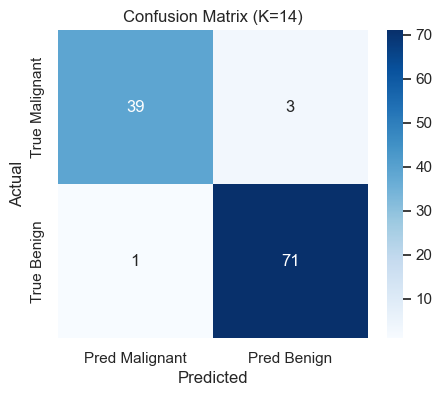

[[39  3]
 [ 1 71]]


In [18]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred Malignant","Pred Benign"],
            yticklabels=["True Malignant","True Benign"])
plt.title(f"Confusion Matrix (K={FINAL_K})"); plt.ylabel("Actual"); plt.xlabel("Predicted")
plt.show()
print(cm)

**The dangerous cell.** With `0 = Malignant`, a **false negative** = a true Malignant tumour
predicted as Benign (top-right cell of the matrix). Clinically that's the worst error — a missed cancer.
That's exactly why *recall on the malignant class* matters more than raw accuracy (discussed in Task 6).

In [19]:
# Recall specifically for the malignant class (the clinically critical one)
rec_malignant = recall_score(y_test, y_pred, pos_label=0)
print(f"Recall for MALIGNANT class (pos_label=0): {rec_malignant:.4f}")

Recall for MALIGNANT class (pos_label=0): 0.9286


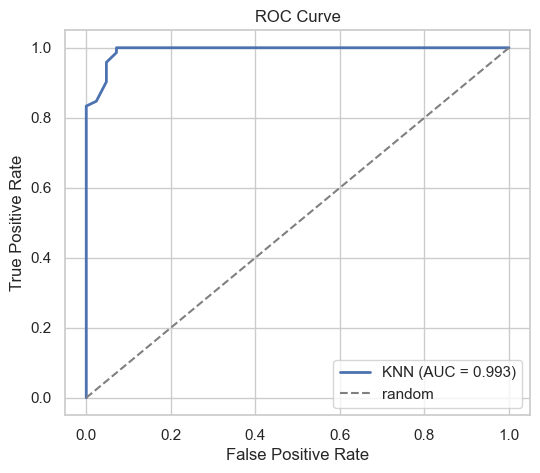

AUC = 0.9926


In [20]:
# ROC curve & AUC
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"KNN (AUC = {roc_auc:.3f})", lw=2)
plt.plot([0,1],[0,1], ls="--", color="gray", label="random")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve"); plt.legend(loc="lower right"); plt.show()
print(f"AUC = {roc_auc:.4f}")

## Task 6 — Comparative Study with Regression (Lab 3)

In Lab 3 (Linear Regression) you evaluated **MAE, MSE, RMSE, R²**. Those measure *how far off* a
continuous prediction is. Classification metrics instead measure *how often the decision is correct*.

| Aspect | Regression (Lab 3) | Classification (Lab 4) |
|---|---|---|
| Output | Continuous value | Discrete class label |
| Evaluation logic | Error-based (magnitude of error) | Decision-based (correct vs wrong) |
| Core metrics | MAE, MSE, RMSE, R² | Accuracy, Precision, Recall, F1, AUC |
| Direction | Lower error = better (R² higher = better) | Higher = better |
| "Perfect" | error = 0, R² = 1 | all metrics = 1 |

**Pairwise comparison asked in the lab**

- **R² vs Accuracy** — both are single "overall goodness" numbers in [0,1] (R² can go negative). R²
  = fraction of variance explained; Accuracy = fraction of correct predictions. Both hide *where* the
  model fails.
- **RMSE vs F1** — RMSE summarizes error magnitude (and punishes large errors); F1 balances precision
  and recall into one number for imbalanced classes. Both are "balanced summary" scores, one for error
  size, one for decision quality.
- **MAE vs Confusion Matrix** — MAE gives the average absolute error as one number; the confusion
  matrix instead breaks results into TP/TN/FP/FN so you see *which kind* of mistake is happening. MAE
  summarizes, the confusion matrix diagnoses.

**Evaluation logic by task type**

- *Continuous prediction* → measure distance between predicted and true numbers (error metrics).
- *Classification* → count correct/incorrect decisions and the *type* of each error (decision metrics).


In [21]:
# Small side-by-side reference table
compare = pd.DataFrame({
    "Regression (Lab 3)": ["MAE","MSE","RMSE","R2 Score"],
    "Measures": ["Mean absolute error","Mean squared error",
                 "Root mean squared error","Variance explained"],
    "Classification (Lab 4)": ["Accuracy","Precision / Recall","F1 Score","ROC-AUC"],
    "Measures ": ["Overall correctness","Correctness per class",
                  "Precision-recall balance","Ranking / separability"],
})
compare

,Regression (Lab 3),Measures,Classification (Lab 4),Measures
0,MAE,Mean absolute error,Accuracy,Overall correctness
1,MSE,Mean squared error,Precision / Recall,Correctness per class
2,RMSE,Root mean squared error,F1 Score,Precision-recall balance
3,R2 Score,Variance explained,ROC-AUC,Ranking / separability


## Inference

- **Regression metrics measure error magnitude.** MAE/MSE/RMSE quantify *how far* predictions are from
  true values; R² states the share of variance explained. They answer "how wrong, on average."
- **Classification metrics measure decision correctness.** Accuracy/Precision/Recall/F1/AUC count how
  often, and in what way, the predicted label matches the true label. They answer "how often right, and
  which errors."
- **Accuracy is insufficient in medical diagnosis.** With class imbalance a model can score high
  accuracy while still missing the rare, critical malignant cases; accuracy treats a missed cancer and a
  false alarm as equally (un)important, which is clinically wrong.
- **Recall and ROC-AUC matter more in healthcare.** Recall on the malignant class directly measures how
  many real cancers we catch (minimizing false negatives), and ROC-AUC measures the model's ability to
  separate classes across all thresholds — both far more aligned with the cost of a missed diagnosis.
- **Overall.** Regression evaluation is error-distance-based on a continuous scale; classification
  evaluation is decision-correctness-based on discrete labels. The right framework depends entirely on
  whether the target is a quantity or a category.


## Task 7 — Analytical Questions

**1. Why is KNN a "lazy" learner?**
It does no training-time model fitting — it just stores the data. All computation (finding nearest
neighbours) happens at prediction time, so "learning" is deferred/lazy.

**2. Why is feature scaling required in KNN?**
KNN uses distances. Unscaled large-magnitude features dominate the distance and small ones are ignored.
Standardizing puts every feature on a comparable scale so each contributes fairly.

**3. Explain the √n heuristic for K.**
A rule of thumb sets the starting K ≈ √(number of training samples). It's a reasonable baseline that
scales with dataset size; an odd value is preferred to avoid ties in binary classification. It's only a
starting point — validation refines it.

**4. Why is cross-validation more reliable than one train-test split?**
A single split is one lucky/unlucky partition. K-fold CV trains and tests on multiple partitions and
averages, giving a lower-variance, more trustworthy estimate of generalization.

**5. How does K affect the bias-variance trade-off?**
Small K = low bias, high variance (jagged boundary, overfits noise). Large K = high bias, low variance
(smooth boundary, can underfit). The best K balances the two.

**6. Why is recall more important than accuracy in cancer prediction?**
A false negative (missed cancer) is far costlier than a false positive. Recall on the malignant class
measures how many real cancers are caught; accuracy can look high while still missing critical cases.

**7. Limitation of very large K?**
The neighbourhood grows so wide it includes far-away, dissimilar points; the model over-smooths, loses
local detail, biases toward the majority class, and gets computationally heavier — underfitting.


## Conclusion

- **Optimal K:** heuristic √n gave a baseline of `K = √n`; validation (10-fold CV) selected the final
  `K` used for evaluation (printed above).
- **Split variations:** test accuracy stayed stable across 80:20 / 70:30 / 90:10, confirming the model
  generalizes; smaller test sets (90:10) give noisier estimates.
- **Model performance:** strong Accuracy, F1 and ROC-AUC on the held-out set; the confusion matrix
  highlights false negatives as the clinically critical error.
- **Regression vs classification:** Lab 3 metrics measure continuous *error magnitude*; Lab 4 metrics
  measure discrete *decision correctness*. Accuracy alone is insufficient in medicine — recall and AUC
  are the more relevant lenses.
